# Bonus Capstone Analysis

Filtering,sorting and Exploration  

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
customers = pd.read_csv("customer_list.csv", sep="|")
stores = pd.read_csv("StoreDetail.csv")
sales = pd.read_csv("StoreSales (1).csv")
products = pd.read_csv("Products.csv")
categories = pd.read_csv("ProductCategories.csv")

In [29]:
sales["Transaction Date"] = pd.to_datetime(
    sales["Transaction Date"]
)

assigned_stores = stores[
    (stores["State"] == "Maryland") |
    (stores["State"] == "Maine")
]

sales_stores = sales.merge(assigned_stores, on="Store ID")

1. Create a list of all transactions from January 2024, sorted by sale amount from highest to lowest.
Which transactions had a sale amount greater than $500?

In [30]:
january_2024 = sales[
    (sales["Transaction Date"].dt.year == 2024) &
    (sales["Transaction Date"].dt.month == 1)
]

january_2024 = january_2024.sort_values(
    "Sale Amount",
    ascending=False
)

january_2024

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
135133,2024-01-09,872,NaN,105341-IT,1763.7
134987,2024-01-09,731,NaN,105341-IT,1763.7
139709,2024-01-31,822,NaN,105341-IT,1763.7
138780,2024-01-27,736,NaN,105341-IT,1763.7
138720,2024-01-27,701,NaN,105341-IT,1763.7
...,...,...,...,...,...
139643,2024-01-31,736,NaN,105444-S,2.4
133337,2024-01-01,901,324.0,105402-S,2.4
138904,2024-01-27,850,NaN,105611-S,2.4
136726,2024-01-17,739,NaN,105444-S,2.4


In [31]:
january_2024[
    january_2024["Sale Amount"] > 500
]

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
135133,2024-01-09,872,NaN,105341-IT,1763.7
134987,2024-01-09,731,NaN,105341-IT,1763.7
139709,2024-01-31,822,NaN,105341-IT,1763.7
138780,2024-01-27,736,NaN,105341-IT,1763.7
138720,2024-01-27,701,NaN,105341-IT,1763.7
...,...,...,...,...,...
139274,2024-01-29,815,NaN,105262-IT,603.5
139391,2024-01-30,718,NaN,105262-IT,603.5
136360,2024-01-15,847,NaN,105262-IT,603.5
134154,2024-01-05,825,NaN,105262-IT,603.5


2. Find all products whose product number begins with 10525. What category and subcategory do they
belong to?

In [32]:
products_10525 = products[
    products["Prod Num"].astype(str).str.startswith("10525")
]

products_10525

,Prod Num,Product,CategoryID,SubcategoryID
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab
5,105253-IT,"Apple iPad Pro (12.9-inch, M2)",120,120-tab
6,105254-IT,Chuwi HiPad Max,120,120-tab
7,105255-IT,Lenovo Yoga Smart Tab,120,120-tab
8,105256-IT,ASUS Vivobook 13 Slate OLED,120,120-tab
9,105257-IT,Samsung Galaxy Tab S9 Ultra,120,120-tab
10,105258-IT,Apple iPad Air (10.9-inch),120,120-tab
11,105259-IT,Teclast T40 Pro,120,120-tab


3. Which stores in your assigned territories had at least one transaction with a sale amount over
$1,000? How many such transactions did each store have?

In [33]:
transactions_1000 = sales_stores[
    sales_stores["Sale Amount"] > 1000
]

transactions_1000.groupby(
    ["State", "Store ID"]
)["Sale Amount"].count()

State     Store ID
Maine     818           93
          819           70
          820           93
          821           82
          822           85
          823           97
Maryland  731           72
          732           84
          733           89
          734          153
          735           86
          736         2241
          737           91
          738           79
          739           90
Name: Sale Amount, dtype: int64

Aggregation & NumPy

4. What is the total sales revenue across all in-store transactions in the dataset? What is the average
transaction amount? What is the standard deviation?

In [34]:
total_revenue = sales["Sale Amount"].sum()

average_sale = sales["Sale Amount"].mean()

standard_deviation = sales["Sale Amount"].std()

print(total_revenue)
print(average_sale)
print(standard_deviation)

45370048.85
135.3808499115266
279.7167248966467


5. Which stores had total revenue above the average store revenue across the full dataset? (Hint: use
np.mean().)

In [35]:
store_revenue = sales.groupby(
    "Store ID"
)["Sale Amount"].sum()

average_revenue = np.mean(store_revenue)

store_revenue[store_revenue > average_revenue]

Store ID
705     917471.53
709     640368.11
724     618846.25
728     541670.66
734     584675.92
736    8708119.00
817     602183.44
835     623163.53
838     597565.68
847     607148.21
850     621565.02
905     637818.90
Name: Sale Amount, dtype: float64

6. What is the total revenue for each product category across all territories, sorted from highest to
lowest? Which category has the most individual transactions?

In [36]:
sales_products = sales.merge(products)

sales_products = sales_products.merge(categories)

category_revenue = sales_products.groupby(
    "Category"
)["Sale Amount"].sum().sort_values(ascending=False)

category_revenue

Category
Technology & Accessories    31891406.58
Textbooks                    7961357.21
Apparel and Merchandise      2043382.60
Art Supplies                 1938358.84
Books (General)              1070718.51
Stationery and Supplies       702088.52
Name: Sale Amount, dtype: float64

7. Across the full dataset, what are the top 10 best-selling individual products by total revenue?

In [37]:
top_products = sales_products.groupby(
    "Prod Num"
)["Sale Amount"].sum().sort_values(ascending=False)

top_products.head(10)

Prod Num
105341-IT    1199316.00
105325-IT    1082151.00
105326-IT    1003136.80
105337-IT     913919.76
105333-IT     900524.00
105334-IT     890257.12
105324-IT     877535.40
105330-IT     876792.28
105332-IT     874421.04
105331-IT     872358.20
Name: Sale Amount, dtype: float64

Merging and Grouping

8. For each transaction in your territories, display the transaction date, sale amount, city, state, and
territory manager. (Requires merging StoreSales with StoreDetail.

In [38]:
sales_stores[[
    "Transaction Date",
    "Sale Amount",
    "Store Location",
    "State",
    "Territory Manager"
]]

,Transaction Date,Sale Amount,Store Location,State,Territory Manager
0,2022-01-01,23.44,Annapolis,Maryland,Shruti Reddy
1,2022-01-01,27.52,Baltimore,Maryland,Shruti Reddy
2,2022-01-01,25.00,Germantown,Maryland,Shruti Reddy
3,2022-01-01,8.00,Howard,Maryland,Shruti Reddy
4,2022-01-01,71.74,North Harford,Maryland,Shruti Reddy
...,...,...,...,...,...
102704,2025-12-31,237.28,Orono,Maine,Erbayne Middleton
102705,2025-12-31,26.52,South Portland,Maine,Erbayne Middleton
102706,2025-12-31,12.40,South Portland,Maine,Erbayne Middleton
102707,2025-12-31,20.36,South Portland,Maine,Erbayne Middleton


9. What is total revenue by region across the full dataset? Which region generates the most revenue?
(Requires merging with StoreDetail and grouping by Region.)

In [39]:
region_revenue = sales.merge(stores)

region_revenue = region_revenue.groupby(
    "Region"
)["Sale Amount"].sum().sort_values(ascending=False)

region_revenue

Region
Northeast    24237526.98
South         7996850.12
East          6723039.53
West          6412632.22
Name: Sale Amount, dtype: float64

10. For each product subcategory in your territories, calculate the total revenue and number of
transactions. Which subcategories are driving the most revenue? (Requires merging StoreSales →
Products → ProductCategories.)

In [40]:
subcategory_revenue = sales_products.groupby(
    "Subcategory"
)["Sale Amount"].sum().sort_values(ascending=False)

subcategory_revenue

Subcategory
Laptops                                      16895405.65
Tablets                                       7935063.86
Software Download                             3415021.04
Business & Economics                          1369833.66
Headphones                                    1304768.52
Calculators                                   1292497.06
Health Sciences                               1128762.30
Social Sciences                               1010821.94
Engineering & Technology                       957803.40
External Accessories                           815391.66
Clothing (T-Shirts, Hoodies, and Jackets)      776448.22
Humanities                                     774214.58
Math and Statistics                            672195.58
Technology and Computing                       595803.45
Science                                        491497.90
Miscellaneous Academic Topics                  443309.11
Drawing and Sketching Tools                    437397.82
Paint Brushes      

11. Using the customer list, identify all rewards members who made purchases in your territories. What
is the average transaction value for rewards members compared to non-rewards customers?
(Requires merging StoreSales with customer_list on RewardsID = cust_id.)

In [41]:
sales["Rewards Customer"] = sales["RewardsID"].notna()

sales.groupby(
    "Rewards Customer"
)["Sale Amount"].mean()

Rewards Customer
False    135.182223
True     137.087200
Name: Sale Amount, dtype: float64

12. Who are the top 10 rewards members by total spend across the full dataset? How many
transactions does each have?

In [42]:
top_rewards = sales.groupby(
    "RewardsID"
)["Sale Amount"].sum().sort_values(ascending=False)

top_rewards.head(10)

RewardsID
245.0    17534.76
180.0    17392.38
74.0     17320.93
47.0     16473.72
375.0    16466.96
280.0    16387.39
242.0    15950.82
409.0    15798.41
99.0     15771.27
400.0    15545.26
Name: Sale Amount, dtype: float64

## Advanced / Stretch

13. Compare year-over-year revenue for your territories. Is each territory trending up or down between
years?

This compares yearly revenue for Maryland and Maine to see if sales increased or decreased between years.

In [43]:
sales_stores["Year"] = sales_stores[
    "Transaction Date"
].dt.year

yearly_revenue = sales_stores.groupby(
    ["State", "Year"]
)["Sale Amount"].sum()

yearly_revenue

State     Year
Maine     2022     279074.94
          2023     450814.79
          2024     452377.73
          2025     694982.29
Maryland  2022    2409967.70
          2023    2813693.20
          2024    2821691.59
          2025    3406262.60
Name: Sale Amount, dtype: float64

14. Identify the single best month and single worst month for each of your territories over the full data
period.

In [44]:
sales_stores["Month"] = sales_stores[
    "Transaction Date"
].dt.month

monthly_totals = sales_stores.groupby(
    ["State", "Month"]
)["Sale Amount"].sum().reset_index()

monthly_totals

,State,Month,Sale Amount
0,Maine,1,146222.69
1,Maine,2,141946.35
2,Maine,3,141410.50
3,Maine,4,144913.03
4,Maine,5,126757.80
5,Maine,6,162300.20
6,Maine,7,165835.38
7,Maine,8,177757.12
8,Maine,9,154003.31
9,Maine,10,189829.63


15. Using your monthly revenue totals, fit a linear regression model to the data and plot the trend line
alongside the monthly revenue chart. Is your territory trending up or down overall?

In [47]:
monthly_revenue = sales_stores.groupby(
    ["State", "Month"]
)["Sale Amount"].sum().reset_index()

maryland = monthly_revenue[
    monthly_revenue["State"] == "Maryland"
]

maine = monthly_revenue[
    monthly_revenue["State"] == "Maine"
]

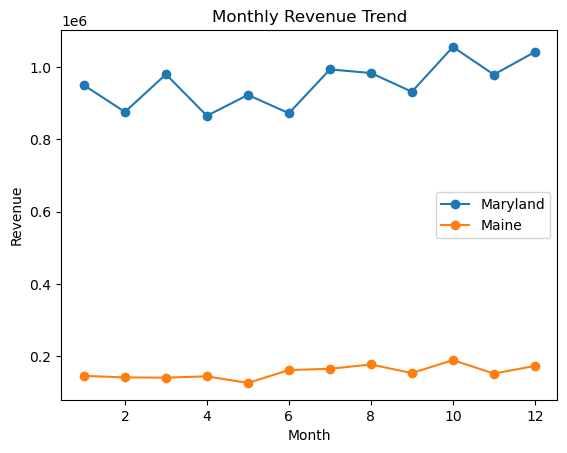

In [48]:
plt.plot(
    maryland["Month"],
    maryland["Sale Amount"],
    marker="o",
    label="Maryland"
)

plt.plot(
    maine["Month"],
    maine["Sale Amount"],
    marker="o",
    label="Maine"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend()

plt.show()